## Fase 1

HERENCIA DE GRUPOS SANGUÍNEOS

Posibles grupos sanguíneos del descendiente:
Grupo A: 18.75%
Grupo B: 18.75%
Grupo AB: 56.25%
Grupo O: 6.25%


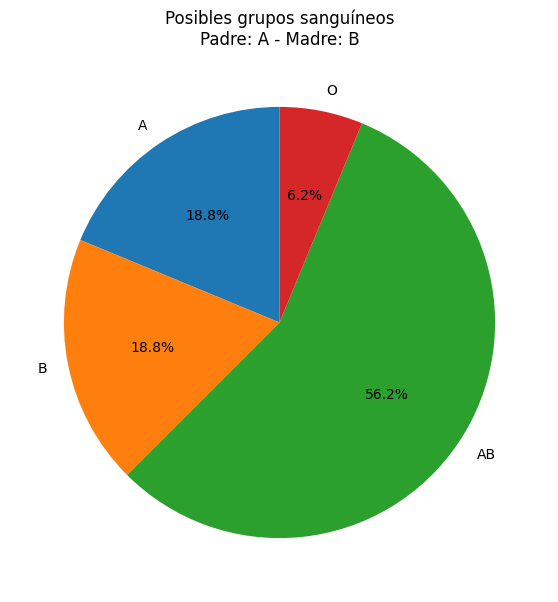

In [6]:
import matplotlib.pyplot as plt


class gruposangDescriptor:
    # Grupos sanguíneos válidos
    GRUPOS_VALIDOS = {"A", "B", "AB", "O"}

    def __set_name__(self, owner, name):
        self.name = name

    def __get__(self, instance, owner):
        if instance is None:
            return self

        return instance.__dict__[self.name]

    def __set__(self, instance, value):
        # Convertir a mayúsculas
        value = value.upper()

        # Permitir 0 como O
        if value == "0":
            value = "O"

        # Comprobar que el grupo es válido
        if value not in self.GRUPOS_VALIDOS:
            raise ValueError(
                "Grupo sanguíneo no válido. Usa A, B, AB u O."
            )

        instance.__dict__[self.name] = value


class Padres:

    # Descriptores de los grupos de los padres
    grupo_padre = gruposangDescriptor()
    grupo_madre = gruposangDescriptor()

    def __init__(self, padre, madre):
        self.grupo_padre = padre
        self.grupo_madre = madre


class Descendencia:

    # Genotipos posibles para cada grupo
    GENOTIPOS = {
        "A": ["AA", "AO"],
        "B": ["BB", "BO"],
        "AB": ["AB"],
        "O": ["OO"]
    }

    def __init__(self, padres):
        self.padres = padres

    def _gametos(self, genotipo):
        # Obtener los alelos
        return list(genotipo)

    def _resultado_genotipo(self, alelo1, alelo2):
        # Combinar los dos alelos
        genotipo = alelo1 + alelo2

        # A y B son codominantes
        if "A" in genotipo and "B" in genotipo:
            return "AB"

        # A domina sobre O
        if "A" in genotipo:
            return "A"

        # B domina sobre O
        if "B" in genotipo:
            return "B"

        # OO produce el grupo O
        return "O"

    def _cruzamiento(self, genotipo_padre, genotipo_madre):
        resultados = []

        # Obtener los alelos posibles
        gametos_padre = self._gametos(genotipo_padre)
        gametos_madre = self._gametos(genotipo_madre)

        # Combinar los alelos
        for alelo_padre in gametos_padre:
            for alelo_madre in gametos_madre:
                resultado = self._resultado_genotipo(
                    alelo_padre,
                    alelo_madre
                )

                resultados.append(resultado)

        return resultados

    def calcular_posibilidades(self):
        resultados = []

        # Obtener los genotipos posibles
        genotipos_padre = self.GENOTIPOS[self.padres.grupo_padre]
        genotipos_madre = self.GENOTIPOS[self.padres.grupo_madre]

        # Calcular las combinaciones
        for genotipo_padre in genotipos_padre:
            for genotipo_madre in genotipos_madre:
                resultados.extend(
                    self._cruzamiento(
                        genotipo_padre,
                        genotipo_madre
                    )
                )

        total = len(resultados)

        # Calcular los porcentajes
        porcentajes = {
            "A": resultados.count("A") / total * 100,
            "B": resultados.count("B") / total * 100,
            "AB": resultados.count("AB") / total * 100,
            "O": resultados.count("O") / total * 100
        }

        # Eliminar grupos con 0%
        return {
            grupo: porcentaje
            for grupo, porcentaje in porcentajes.items()
            if porcentaje > 0
        }

    def mostrar_resultados(self):
        resultados = self.calcular_posibilidades()

        print("\nPosibles grupos sanguíneos del descendiente:")

        # Mostrar los porcentajes
        for grupo, porcentaje in resultados.items():
            print(f"Grupo {grupo}: {porcentaje:.2f}%")

        self._mostrar_grafico(resultados)

    def _mostrar_grafico(self, resultados):
        grupos = list(resultados.keys())
        porcentajes = list(resultados.values())

        # Crear gráfico circular
        plt.figure(figsize=(7, 7))

        plt.pie(
            porcentajes,
            labels=grupos,
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title(
            f"Posibles grupos sanguíneos\n"
            f"Padre: {self.padres.grupo_padre} - "
            f"Madre: {self.padres.grupo_madre}"
        )

        plt.show()


def main():
    print("HERENCIA DE GRUPOS SANGUÍNEOS")

    while True:
        try:
            padre = input(
                "Introduce el grupo sanguíneo del padre (A, B, AB, O/0): "
            )

            madre = input(
                "Introduce el grupo sanguíneo de la madre (A, B, AB, O/0): "
            )

            # Crear los padres
            padres = Padres(padre, madre)

            # Calcular la descendencia
            descendencia = Descendencia(padres)

            descendencia.mostrar_resultados()

            break

        except ValueError as error:
            print(f"Error: {error}")


if __name__ == "__main__":
    main()

## Fase 2

ANÁLISIS DE GRUPO SANGUÍNEO
Padre: A
Madre: B

Posibles grupos sanguíneos:
Grupo A: 18.75%
Grupo B: 18.75%
Grupo AB: 56.25%
Grupo O: 6.25%


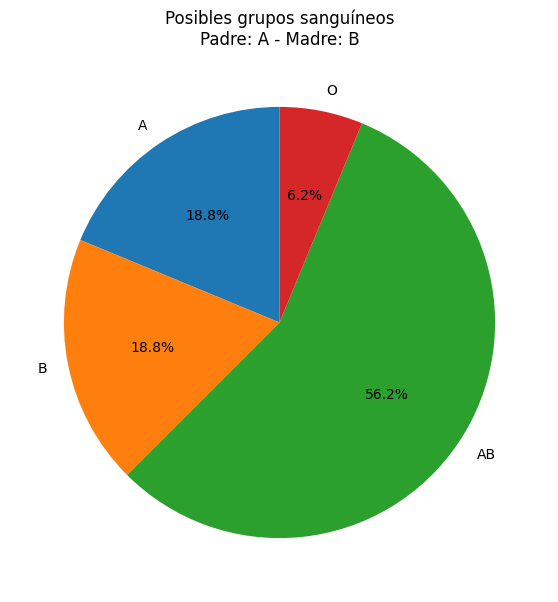

ANÁLISIS DE GRUPO SANGUÍNEO
Padre: O
Madre: A

Posibles grupos sanguíneos:
Grupo A: 75.00%
Grupo O: 25.00%


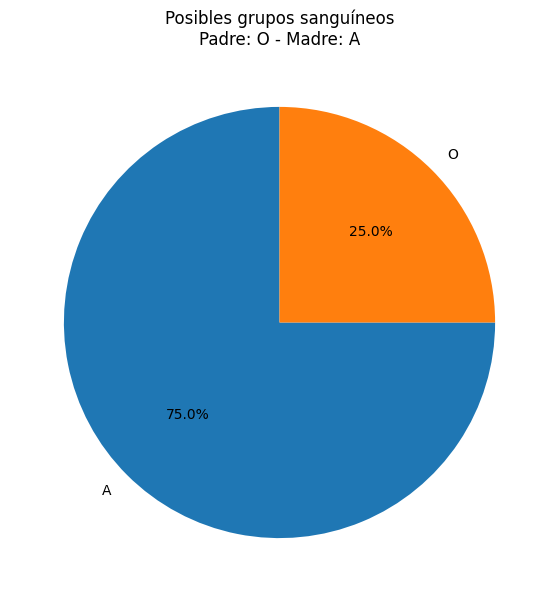

ANÁLISIS DE GRUPO SANGUÍNEO
Padre: AB
Madre: O

Posibles grupos sanguíneos:
Grupo A: 50.00%
Grupo B: 50.00%


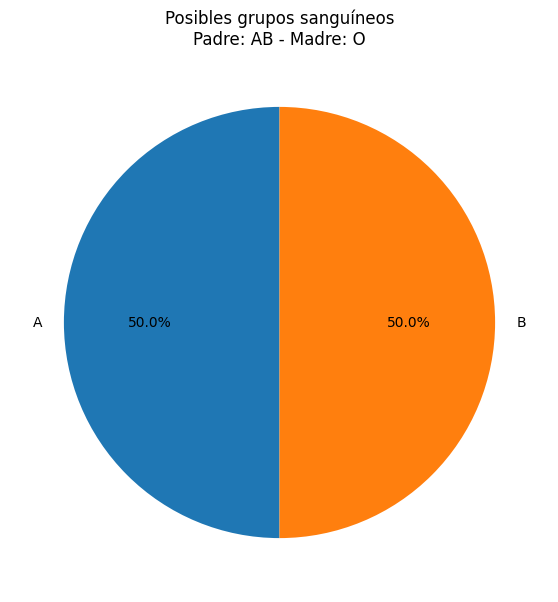

In [8]:
import json
from datetime import datetime
import matplotlib.pyplot as plt


class gruposangDescriptor:
    # Grupos sanguíneos válidos
    GRUPOS_VALIDOS = {"A", "B", "AB", "O"}

    def __set_name__(self, owner, name):
        self.name = name

    def __get__(self, instance, owner):
        if instance is None:
            return self

        return instance.__dict__[self.name]

    def __set__(self, instance, value):
        # Convertir la entrada a mayúsculas
        value = value.upper()

        # Permitir 0 como O
        if value == "0":
            value = "O"

        # Comprobar que el grupo es válido
        if value not in self.GRUPOS_VALIDOS:
            raise ValueError(
                "Grupo sanguíneo no válido. Usa A, B, AB u O."
            )

        instance.__dict__[self.name] = value


class Padres:

    # Descriptores para los grupos de los padres
    grupo_padre = gruposangDescriptor()
    grupo_madre = gruposangDescriptor()

    def __init__(self, padre, madre):
        self.grupo_padre = padre
        self.grupo_madre = madre


class Descendencia:

    # Genotipos posibles para cada grupo
    GENOTIPOS = {
        "A": ["AA", "AO"],
        "B": ["BB", "BO"],
        "AB": ["AB"],
        "O": ["OO"]
    }

    def __init__(self, padres):
        self.padres = padres

    def _gametos(self, genotipo):
        # Obtener los alelos
        return list(genotipo)

    def _resultado_genotipo(self, alelo1, alelo2):
        # Combinar los dos alelos
        genotipo = alelo1 + alelo2

        # A y B son codominantes
        if "A" in genotipo and "B" in genotipo:
            return "AB"

        # A domina sobre O
        if "A" in genotipo:
            return "A"

        # B domina sobre O
        if "B" in genotipo:
            return "B"

        # Solo OO produce O
        return "O"

    def _cruzamiento(self, genotipo_padre, genotipo_madre):
        resultados = []

        # Obtener los alelos posibles
        gametos_padre = self._gametos(genotipo_padre)
        gametos_madre = self._gametos(genotipo_madre)

        # Combinar los alelos
        for alelo_padre in gametos_padre:
            for alelo_madre in gametos_madre:
                resultado = self._resultado_genotipo(
                    alelo_padre,
                    alelo_madre
                )

                resultados.append(resultado)

        return resultados

    def calcular_posibilidades(self):
        resultados = []

        # Obtener los genotipos posibles
        genotipos_padre = self.GENOTIPOS[self.padres.grupo_padre]
        genotipos_madre = self.GENOTIPOS[self.padres.grupo_madre]

        # Calcular las combinaciones
        for genotipo_padre in genotipos_padre:
            for genotipo_madre in genotipos_madre:
                resultados.extend(
                    self._cruzamiento(
                        genotipo_padre,
                        genotipo_madre
                    )
                )

        total = len(resultados)

        # Calcular los porcentajes
        porcentajes = {
            "A": resultados.count("A") / total * 100,
            "B": resultados.count("B") / total * 100,
            "AB": resultados.count("AB") / total * 100,
            "O": resultados.count("O") / total * 100
        }

        # Eliminar grupos con 0%
        return {
            grupo: porcentaje
            for grupo, porcentaje in porcentajes.items()
            if porcentaje > 0
        }

    def mostrar_grafico(self, resultados):
        grupos = list(resultados.keys())
        porcentajes = list(resultados.values())

        # Crear gráfico circular
        plt.figure(figsize=(7, 7))

        plt.pie(
            porcentajes,
            labels=grupos,
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title(
            f"Posibles grupos sanguíneos\n"
            f"Padre: {self.padres.grupo_padre} - "
            f"Madre: {self.padres.grupo_madre}"
        )

        plt.show()


class GestorJSON:

    def __init__(self, archivo_entrada, archivo_salida):
        self.archivo_entrada = archivo_entrada
        self.archivo_salida = archivo_salida

    def leer_padres(self):
        # Leer los datos del archivo JSON
        with open(
            self.archivo_entrada,
            "r",
            encoding="utf-8"
        ) as archivo:
            return json.load(archivo)

    def guardar_resultado(self, resultado):
        try:
            # Leer resultados anteriores
            with open(
                self.archivo_salida,
                "r",
                encoding="utf-8"
            ) as archivo:
                resultados = json.load(archivo)

        except (FileNotFoundError, json.JSONDecodeError):
            # Crear una lista si no existe el archivo
            resultados = []

        # Añadir el nuevo resultado
        resultados.append(resultado)

        # Guardar los resultados
        with open(
            self.archivo_salida,
            "w",
            encoding="utf-8"
        ) as archivo:
            json.dump(
                resultados,
                archivo,
                indent=4,
                ensure_ascii=False
            )


def main():

    # Crear el gestor de archivos
    gestor = GestorJSON(
        "padres.json",
        "resultados.json"
    )

    try:
        # Leer los registros de entrada
        registros = gestor.leer_padres()

    except (FileNotFoundError, json.JSONDecodeError) as error:
        print(f"Error al leer el archivo JSON: {error}")
        return

    # Analizar cada registro
    for registro in registros:

        try:
            # Crear los padres
            padres = Padres(
                registro["padre"],
                registro["madre"]
            )

            # Calcular la descendencia
            descendencia = Descendencia(padres)

            resultados = descendencia.calcular_posibilidades()

            # Obtener la fecha del análisis
            fecha = datetime.now().strftime(
                "%Y-%m-%d %H:%M:%S"
            )

            # Preparar los datos para guardar
            resultado_guardar = {
                "fecha": fecha,
                "padre": padres.grupo_padre,
                "madre": padres.grupo_madre,
                "resultados": resultados
            }

            # Guardar el análisis
            gestor.guardar_resultado(
                resultado_guardar
            )

            print("ANÁLISIS DE GRUPO SANGUÍNEO")

            print(f"Padre: {padres.grupo_padre}")
            print(f"Madre: {padres.grupo_madre}")

            print("\nPosibles grupos sanguíneos:")

            # Mostrar los resultados
            for grupo, porcentaje in resultados.items():
                print(
                    f"Grupo {grupo}: "
                    f"{porcentaje:.2f}%"
                )

            # Mostrar el gráfico
            descendencia.mostrar_grafico(resultados)

        except (KeyError, ValueError) as error:
            print(f"Error al procesar el registro: {error}")


if __name__ == "__main__":
    main()

## Fase 3

In [10]:
import json
import shutil
from datetime import datetime
from pathlib import Path
import matplotlib.pyplot as plt


class gruposangDescriptor:
    # Grupos sanguíneos válidos
    GRUPOS_VALIDOS = {"A", "B", "AB", "O"}

    def __set_name__(self, owner, name):
        self.name = name

    def __get__(self, instance, owner):
        if instance is None:
            return self

        return instance.__dict__[self.name]

    def __set__(self, instance, value):
        # Convertir a mayúsculas
        value = value.upper()

        # Permitir 0 como O
        if value == "0":
            value = "O"

        # Comprobar que el grupo es válido
        if value not in self.GRUPOS_VALIDOS:
            raise ValueError(
                "Grupo sanguíneo no válido. Usa A, B, AB u O."
            )

        instance.__dict__[self.name] = value


class Padres:

    # Descriptores de los grupos de los padres
    grupo_padre = gruposangDescriptor()
    grupo_madre = gruposangDescriptor()

    def __init__(self, padre, madre):
        self.grupo_padre = padre
        self.grupo_madre = madre


class Descendencia:

    # Genotipos posibles para cada grupo
    GENOTIPOS = {
        "A": ["AA", "AO"],
        "B": ["BB", "BO"],
        "AB": ["AB"],
        "O": ["OO"]
    }

    def __init__(self, padres):
        self.padres = padres

    def _gametos(self, genotipo):
        # Obtener los alelos
        return list(genotipo)

    def _resultado_genotipo(self, alelo1, alelo2):
        # Combinar los dos alelos
        genotipo = alelo1 + alelo2

        # A y B son codominantes
        if "A" in genotipo and "B" in genotipo:
            return "AB"

        # A domina sobre O
        if "A" in genotipo:
            return "A"

        # B domina sobre O
        if "B" in genotipo:
            return "B"

        # OO produce el grupo O
        return "O"

    def _cruzamiento(self, genotipo_padre, genotipo_madre):
        resultados = []

        # Obtener los alelos posibles
        gametos_padre = self._gametos(genotipo_padre)
        gametos_madre = self._gametos(genotipo_madre)

        # Combinar los alelos
        for alelo_padre in gametos_padre:
            for alelo_madre in gametos_madre:
                resultado = self._resultado_genotipo(
                    alelo_padre,
                    alelo_madre
                )

                resultados.append(resultado)

        return resultados

    def calcular_posibilidades(self):
        resultados = []

        # Obtener los genotipos posibles
        genotipos_padre = self.GENOTIPOS[self.padres.grupo_padre]
        genotipos_madre = self.GENOTIPOS[self.padres.grupo_madre]

        # Calcular las combinaciones
        for genotipo_padre in genotipos_padre:
            for genotipo_madre in genotipos_madre:
                resultados.extend(
                    self._cruzamiento(
                        genotipo_padre,
                        genotipo_madre
                    )
                )

        total = len(resultados)

        # Calcular los porcentajes
        porcentajes = {
            "A": resultados.count("A") / total * 100,
            "B": resultados.count("B") / total * 100,
            "AB": resultados.count("AB") / total * 100,
            "O": resultados.count("O") / total * 100
        }

        # Eliminar grupos con 0%
        return {
            grupo: porcentaje
            for grupo, porcentaje in porcentajes.items()
            if porcentaje > 0
        }

    def mostrar_grafico(self, resultados):
        grupos = list(resultados.keys())
        porcentajes = list(resultados.values())

        # Crear gráfico circular
        plt.figure(figsize=(7, 7))

        plt.pie(
            porcentajes,
            labels=grupos,
            autopct="%1.1f%%",
            startangle=90
        )

        plt.title(
            f"Posibles grupos sanguíneos\n"
            f"Padre: {self.padres.grupo_padre} - "
            f"Madre: {self.padres.grupo_madre}"
        )

        plt.show()


class GestorArchivos:

    def __init__(self):
        # Crear las carpetas necesarias
        self.data = Path("data")
        self.pending = self.data / "pending"
        self.done = self.data / "done"
        self.results = self.data / "results"

        self.pending.mkdir(parents=True, exist_ok=True)
        self.done.mkdir(parents=True, exist_ok=True)
        self.results.mkdir(parents=True, exist_ok=True)

    def obtener_archivos_pendientes(self):
        # Obtener los archivos JSON pendientes
        return list(self.pending.glob("*.json"))

    def leer_archivo(self, archivo):
        # Leer el archivo JSON
        with open(
            archivo,
            "r",
            encoding="utf-8"
        ) as fichero:
            return json.load(fichero)

    def guardar_resultado(self, nombre_archivo, resultado):
        # Crear el nombre del archivo de resultados
        archivo_resultado = self.results / nombre_archivo

        # Guardar el resultado en JSON
        with open(
            archivo_resultado,
            "w",
            encoding="utf-8"
        ) as fichero:
            json.dump(
                resultado,
                fichero,
                indent=4,
                ensure_ascii=False
            )

    def mover_a_done(self, archivo):
        # Copiar el archivo a done
        destino = self.done / archivo.name
        shutil.copy2(archivo, destino)

        # Eliminar el archivo de pending
        archivo.unlink()


def procesar_archivo(gestor, archivo):

    try:
        # Leer los datos del archivo
        registros = gestor.leer_archivo(archivo)

        resultados_archivo = []

        # Analizar cada registro
        for registro in registros:

            # Crear los padres
            padres = Padres(
                registro["padre"],
                registro["madre"]
            )

            # Calcular la descendencia
            descendencia = Descendencia(padres)

            resultados = descendencia.calcular_posibilidades()

            # Crear el resultado
            resultado = {
                "fecha": datetime.now().strftime(
                    "%Y-%m-%d %H:%M:%S"
                ),
                "padre": padres.grupo_padre,
                "madre": padres.grupo_madre,
                "resultados": resultados
            }

            resultados_archivo.append(resultado)

            # Mostrar los resultados por pantalla
            print("ANÁLISIS DE GRUPO SANGUÍNEO")

            print(f"Padre: {padres.grupo_padre}")
            print(f"Madre: {padres.grupo_madre}")

            print("\nPosibles grupos sanguíneos:")

            for grupo, porcentaje in resultados.items():
                print(
                    f"Grupo {grupo}: "
                    f"{porcentaje:.2f}%"
                )

            # Mostrar gráfico
            descendencia.mostrar_grafico(resultados)

        # Guardar todos los resultados del archivo
        gestor.guardar_resultado(
            archivo.name,
            resultados_archivo
        )

        # Mover el archivo procesado a done
        gestor.mover_a_done(archivo)

        print(f"\nArchivo procesado: {archivo.name}")

    except (KeyError, ValueError, json.JSONDecodeError) as error:
        print(
            f"\nError al procesar {archivo.name}: {error}"
        )


def main():

    print("GESTIÓN DE ARCHIVOS - GRUPOS SANGUÍNEOS")

    # Crear el gestor de archivos
    gestor = GestorArchivos()

    # Obtener los archivos pendientes
    archivos = gestor.obtener_archivos_pendientes()

    if not archivos:
        print("\nNo hay archivos pendientes de analizar.")
        return

    print(
        f"\nSe han encontrado "
        f"{len(archivos)} archivo(s) pendiente(s)."
    )

    # Procesar todos los archivos
    for archivo in archivos:
        procesar_archivo(gestor, archivo)


if __name__ == "__main__":
    main()

GESTIÓN DE ARCHIVOS - GRUPOS SANGUÍNEOS

No hay archivos pendientes de analizar.
